In [1]:
import numpy as pd
import pandas as pd

In [2]:
df=pd.read_csv('Ecommerce_Sales_Data_2024_2025.csv')

In [3]:
df.head()
df.tail()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
4995,14996,2024-06-25,Nishith Kulkarni,East,Kolkata,Books,Fiction,Fiction Veritatis,3,60671,0,182013.0,11853.15,Debit Card
4996,14997,2024-12-22,Aaina Chander,North,Jaipur,Toys,Doll,Doll Nulla,5,70048,0,350240.0,31237.23,Credit Card
4997,14998,2025-04-15,Dhanush Gara,South,Bangalore,Beauty,Lipstick,Lipstick Eaque,1,42162,15,35837.7,7827.50,Debit Card
4998,14999,2024-07-08,Divyansh Malhotra,East,Kolkata,Electronics,Smartwatch,Smartwatch Adipisci,4,13568,10,48844.8,6603.86,Credit Card
4999,15000,2024-02-04,Aarush Walla,West,Goa,Clothing,Kids Wear,Kids Wear Repellat,1,76762,10,69085.8,5785.85,Net Banking


In [4]:
df.dtypes

Order ID           int64
Order Date        object
Customer Name     object
Region            object
City              object
Category          object
Sub-Category      object
Product Name      object
Quantity           int64
Unit Price         int64
Discount           int64
Sales            float64
Profit           float64
Payment Mode      object
dtype: object

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Unit Price'] = df['Unit Price'].astype(float)
df['Discount'] = df['Discount'].astype(float)

df['Order ID'] = df['Order ID'].astype(str)

In [6]:
df.dtypes

Order ID                 object
Order Date       datetime64[ns]
Customer Name            object
Region                   object
City                     object
Category                 object
Sub-Category             object
Product Name             object
Quantity                  int64
Unit Price              float64
Discount                float64
Sales                   float64
Profit                  float64
Payment Mode             object
dtype: object

In [7]:
df.isnull().sum()

Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64

In [8]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer Name'].nunique()

print(total_sales, total_profit, total_orders, total_customers)

533666024.35 79708734.91 5000 4844


<Axes: xlabel='Order Date'>

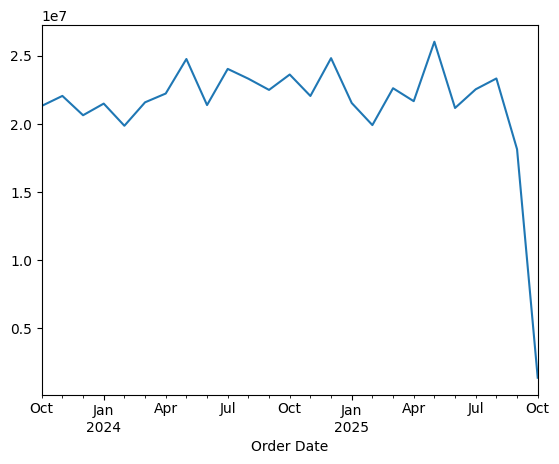

In [9]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot()

In [10]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Home Decor     57233222.35
Furniture      56647187.90
Clothing       55053908.30
Books          54932643.00
Kitchen        54227902.30
Electronics    52587883.95
Toys           52227366.45
Sports         52069397.25
Beauty         50803409.70
Groceries      47883103.15
Name: Sales, dtype: float64

In [11]:
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

Sub-Category
Sofa             15185544.25
Lamp             14767580.20
Tennis Racket    12934015.25
Women's Wear     12646602.90
Fiction          12376112.80
Non-Fiction      12219033.75
Bed              12211588.60
Juicer           12194033.75
Headphones       12058508.60
Football         11779009.10
Accessories      11719871.50
Face Cream       11691198.95
Refrigerator     11448638.30
Vase             11426256.50
Men's Wear       11386655.50
Smartwatch       11157244.85
RC Car           11108554.55
Rice             11020850.05
Cookware Set     10961496.75
Wall Art         10712747.85
Board Game       10615672.05
Puzzle           10595979.25
Lipstick         10567432.75
Camera           10547720.10
Cabinet          10367085.35
Cushion          10333401.50
Textbook         10285597.40
Chair            10272174.00
Perfume          10142457.15
Comics           10061464.85
Clock             9993236.30
Biography         9990434.20
Doll              9984889.90
Mixer Grinder     9948412.45
S

In [12]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
North    1.435782e+08
East     1.358116e+08
West     1.310460e+08
South    1.232302e+08
Name: Sales, dtype: float64

In [13]:
df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

City
Bangalore      29989840.85
Lucknow        29901483.40
Guwahati       29606888.90
Chandigarh     29331057.35
Jaipur         29319402.90
Amritsar       28746184.20
Surat          28532934.65
Patna          27702815.20
Bhubaneswar    27088786.45
Ranchi         26948513.25
Name: Sales, dtype: float64

In [14]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

Product Name
Headphones Accusantium     857184.20
Spices Quibusdam           687651.25
Accessories Repellendus    687083.30
Bed Tenetur                670994.80
Laptop Similique           666640.60
Lamp Enim                  665920.20
Shampoo Commodi            659546.60
Lamp Veritatis             652909.50
Men's Wear Voluptatibus    649048.00
Textbook Omnis             633246.25
Name: Sales, dtype: float64

In [15]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Furniture      8693087.03
Home Decor     8556846.94
Clothing       8445750.29
Books          8076273.29
Electronics    8042133.88
Toys           7986871.44
Kitchen        7879573.29
Sports         7739430.04
Beauty         7213436.07
Groceries      7075332.64
Name: Profit, dtype: float64

In [16]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

Customer Name
Aaryahi Madan         650151.9
Kimaya Vala           490935.0
Badal Rao             485698.0
Adira Dhingra         479389.0
Sumer Mann            469937.0
Nayantara Majumdar    459763.5
Prerak Shere          451862.4
Bhamini Sane          441410.6
Samarth Wagle         427715.5
Arhaan Basu           426563.6
Name: Sales, dtype: float64

In [17]:
df.groupby('Payment Mode')['Sales'].sum()

Payment Mode
COD            1.088814e+08
Credit Card    1.060271e+08
Debit Card     1.053464e+08
Net Banking    1.114655e+08
UPI            1.019456e+08
Name: Sales, dtype: float64

#doing rfm

In [18]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

In [19]:
rfm = df.groupby('Customer Name').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Order ID': 'nunique',                                  # Frequency
    'Sales': 'sum'                                          # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer Name,,,
Aaina Balasubramanian,643,1,158876.8
Aaina Bhargava,15,1,26411.9
Aaina Bir,133,1,231044.0
Aaina Chander,286,1,350240.0
Aaina Chandran,572,1,43747.5


In [20]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [21]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + \
                   rfm['F_score'].astype(str) + \
                   rfm['M_score'].astype(str)

In [22]:
def segment(row):
    if row['RFM_Score'] == '444':
        return 'Champions'
    elif row['R_score'] == 4 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3 and row['F_score'] >= 2:
        return 'Potential Loyalists'
    elif row['R_score'] == 1:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [23]:
rfm['Segment'].value_counts()

Segment
Others                 1817
At Risk                1207
Potential Loyalists    1188
Loyal Customers         525
Champions               107
Name: count, dtype: int64

In [24]:
rfm.groupby('Segment')['Monetary'].mean()

Segment
At Risk                104621.133057
Champions              247090.540187
Loyal Customers         88846.252190
Others                 109545.853797
Potential Loyalists    113855.665152
Name: Monetary, dtype: float64

In [25]:
df.to_csv('cleaned_ecommerce_data.csv', index=False)